In [7]:
import numpy as np
import pandas as pd
import scanpy as sc
import gc
from matplotlib import pyplot as plt
%run ../common.py
%run ../commonvis.py

# Load data

In [12]:
allresults = []
for dset, vimaD, pheno, suff in [
    ('RA', '../RA/_results/cc_fstar.h5ad', 'RA', ''),
    ('UC', '../UC/_results/cc_uc.h5ad', 'UC', ''),
    ('UC', '../UC/_results/cc_tnf.h5ad', 'TNFi', '2'),
    ('ALZ', '../ALZ/_results/cc_dementia.h5ad', 'Dementia', '')
    ]:
    myresults = collate_cc(dset, D=sc.read_h5ad(vimaD), suffix=suff)
    myresults['pheno'] = pheno
    allresults.append(myresults)
    gc.collect()
results = pd.concat(allresults)

canvas noharm
patchavgmm noharm
stagate noharm
stagate harm
patchavgmm harm
canvas harm
stagate noharm
patchavgmm noharm
patchcelltypeabundance noharm
tissuemosaic noharm
canvas noharm
utag noharm
canvas harm
patchcelltypeabundance harm
utag harm
patchavgmm harm
stagate harm
tissuemosaic harm
stagate noharm
patchavgmm noharm
patchcelltypeabundance noharm
tissuemosaic noharm
canvas noharm
utag noharm
canvas harm
patchcelltypeabundance harm
utag harm
patchavgmm harm
stagate harm
tissuemosaic harm
patchavgmm noharm
stagate noharm
tissuemosaic noharm
patchcelltypeabundance noharm
utag noharm
cellcharter noharm
canvas noharm
utag harm
stagate harm
cellcharter harm
canvas harm
tissuemosaic harm
patchcelltypeabundance harm
patchavgmm harm


In [99]:
results['method'] = results.index
results['dataset'] = results.pheno.map({'RA': 'RA subtypes',
                              'UC':'UC vs healthy',
                              'TNFi':'TNFi vs no',
                              'Dementia':'Dementia vs control'})
results.to_csv('_results/allbenchmarking.csv')

# Make figures

In [123]:
def make_plot(df):
    df_plot = df.copy()
    df_plot['neglog10p'] = -np.log10(df_plot['p'].clip(upper=0.9))

    datasets = df_plot['dataset'].unique()
    methods = df_plot['method'].unique()

    fig, axes = plt.subplots(1, len(datasets), figsize=(3 * len(datasets), 5), sharey=True)

    for i, dataset in enumerate(datasets):
        ax = axes[i] if len(datasets) > 1 else axes
        sub = df_plot[df_plot['dataset'] == dataset]
        
        x = np.arange(len(methods))
        bar_width = 0.8
        p_vals = []
        frac_neg = []
        frac_pos = []

        for j, method in enumerate(methods):
            row = sub[sub['method'] == method]
            if not row.empty:
                p_vals.append(row['neglog10p'].values[0])
                frac_neg.append(row['frac_neg'].values[0])
                frac_pos.append(row['frac_pos'].values[0])
            else:
                # Placeholder zeros for bars
                p_vals.append(0)
                frac_neg.append(0)
                frac_pos.append(0)

                # Determine label type
                if dataset in ['RA subtypes', 'UC vs healthy', 'Dementia vs control']:
                    label = 'NR'
                elif dataset == 'TNFi':
                    label = 'NA'
                else:
                    label = 'NA'  # fallback

                # Annotate with label
                ax.text(j, 0.1, label, ha='center', va='bottom', fontsize=9, color='black')

        # Plot upward P bars
        ax.bar(x, p_vals, color="#00d5ff", width=bar_width)

        # Plot downward stacked bars
        ax.bar(x, -4*np.array(frac_pos), color='red', width=bar_width, label='Positively associated')
        ax.bar(x, -4*np.array(frac_neg), bottom=-4*np.array(frac_pos),
            color='blue', width=bar_width, label='Negatively associated')
        ax.axhline(y=-np.log10(0.05), ls='--', color='gray')

        ax.set_xticks(x)
        ax.set_xticklabels([methodnames[m] for m in methods], rotation=45, ha='right')
        ax.set_yticks([-2,-1,0,1,2,3])
        ax.set_yticklabels(['50%', '25%', '0', '1', '2', '3'])
        ax.set_title(dataset)
        ax.axhline(0, color='black', lw=0.5)

    ### label y-axis
    # Get y-limits to position the text dynamically
    ymin, ymax = axes[0].get_ylim()

    # Label for the top (P-values)
    axes[0].text(
        -2.5,                     # x-position (adjust as needed)
        ymax * 0.5,               # y-position in upper half
        '$-\\log_{10}(P)$', 
        rotation=90,
        va='center',
        ha='center',
    )

    # Label for the bottom (Associations)
    axes[0].text(
        -2.5,
        ymin * 0.5,               # y-position in lower half
        '%Sig. spatial units', 
        rotation=90,
        va='center', 
        ha='center',
    )

    for ax in axes:
        ax.spines[['right', 'top']].set_visible(False)
    axes[-1].legend(loc='lower right')

    plt.tight_layout()

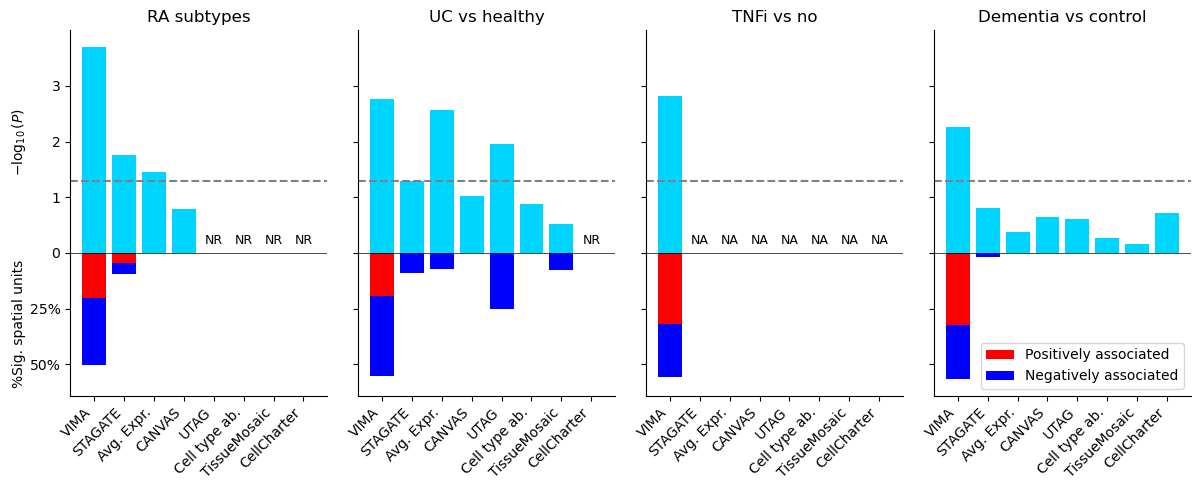

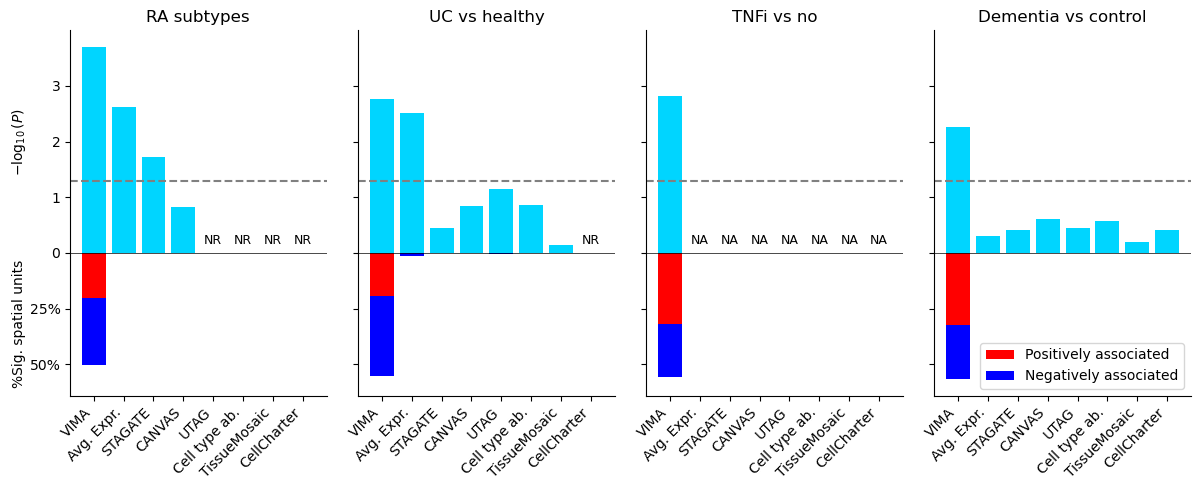

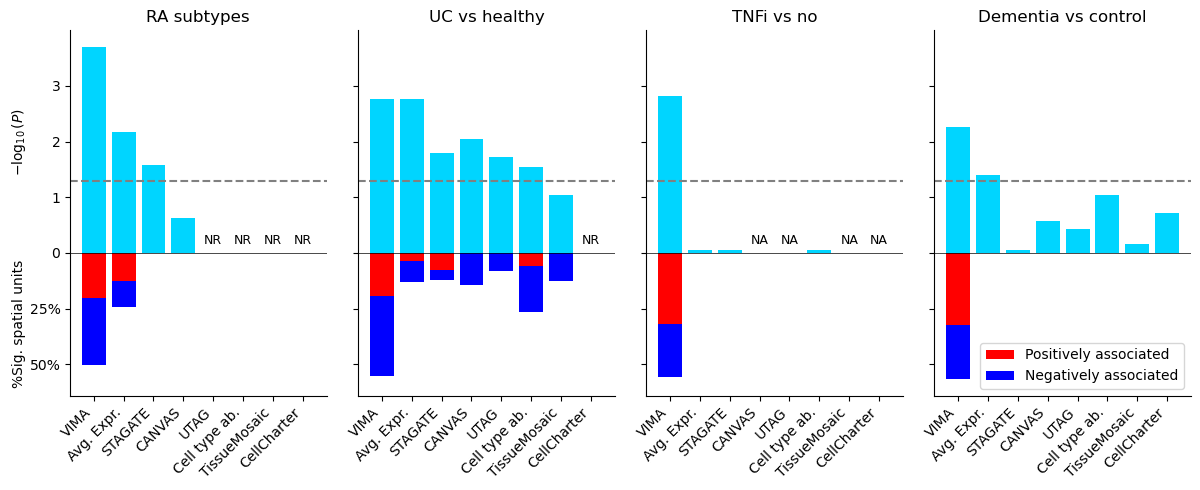

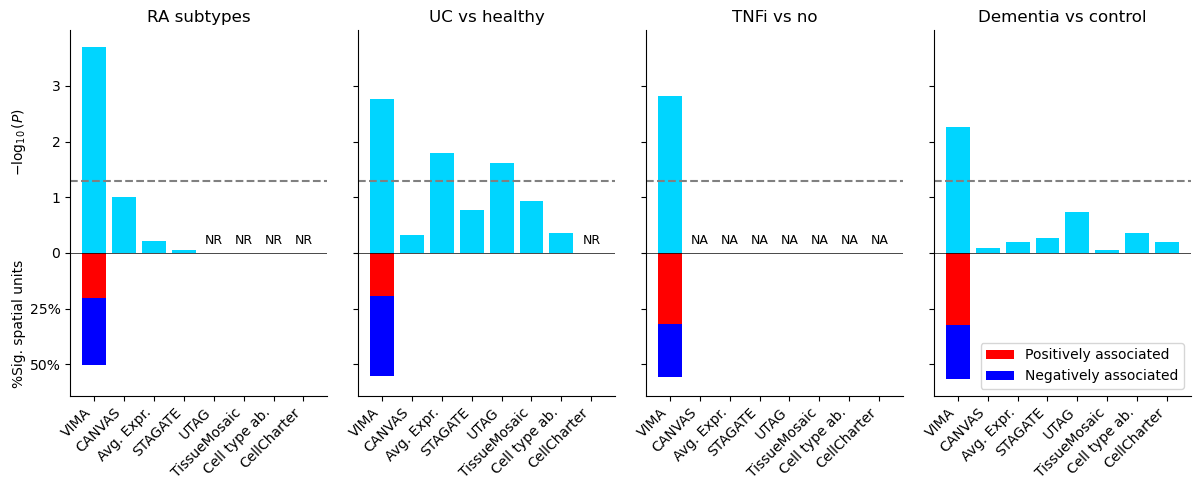

In [124]:
df = results[~(results.microniche == True)&~(results.harmonized == True)&~(results.bonferroni == True)].copy()
make_plot(df)
plt.savefig('../_supp/fig.benchmark.default.png', dpi=800)
plt.show()

df = results[~(results.microniche == False)&~(results.harmonized == True)&~(results.bonferroni == True)].copy()
make_plot(df)
plt.savefig('../_supp/fig.benchmark.microniche.png', dpi=800)

df = results[~(results.microniche == True)&~(results.harmonized == False)&~(results.bonferroni == True)].copy()
make_plot(df)
plt.savefig('../_supp/fig.benchmark.harmonized.png', dpi=800)

df = results[~(results.microniche == True)&~(results.harmonized == True)&~(results.bonferroni == False)].copy()
make_plot(df)
plt.savefig('../_supp/fig.benchmark.bonferroni.png', dpi=800)